In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Loading the dataset

In [3]:
from google.colab import files
uploaded = files.upload()


# Replace file name if needed
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)


print("Data Loaded Successfully! Shape:", df.shape)
df.head()

Saving fraud_1000_rows.xlsx to fraud_1000_rows (1).xlsx
Data Loaded Successfully! Shape: (1000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Exploring the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            1000 non-null   int64  
 1   type            1000 non-null   object 
 2   amount          1000 non-null   float64
 3   nameOrig        1000 non-null   object 
 4   oldbalanceOrg   1000 non-null   float64
 5   newbalanceOrig  1000 non-null   float64
 6   nameDest        1000 non-null   object 
 7   oldbalanceDest  1000 non-null   float64
 8   newbalanceDest  1000 non-null   float64
 9   isFraud         1000 non-null   int64  
 10  isFlaggedFraud  1000 non-null   int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 86.1+ KB
None
         step        amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count  1000.0  1.000000e+03   1.000000e+03    1.000000e+03    1.000000e+03   
mean      1.0  1.181995e+05   8.646043e+05    8.849988e+05    6.657141e+05   
std    

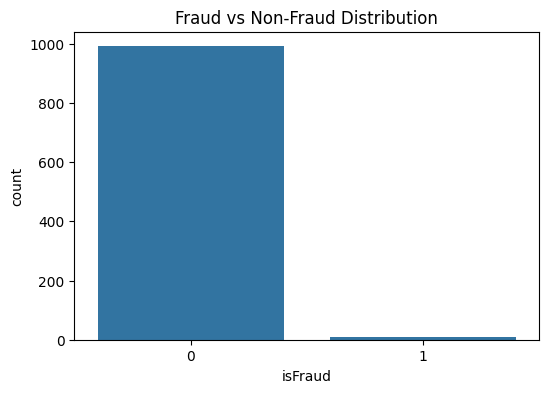

In [4]:
print(df.info())
print(df.describe())
print(df.isnull().sum())


# Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['isFraud'])
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

Preprocessing

In [5]:
# Drop columns that may not be numeric or relevant
# Adjust based on your dataset
X = df.drop(['isFraud'], axis=1)
y = df['isFraud']


# Convert categorical to numeric if present
X = pd.get_dummies(X, drop_first=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

Logistic regression

===== Logistic Regression =====
Accuracy: 0.9933333333333333
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       298
           1       0.00      0.00      0.00         2

    accuracy                           0.99       300
   macro avg       0.50      0.50      0.50       300
weighted avg       0.99      0.99      0.99       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


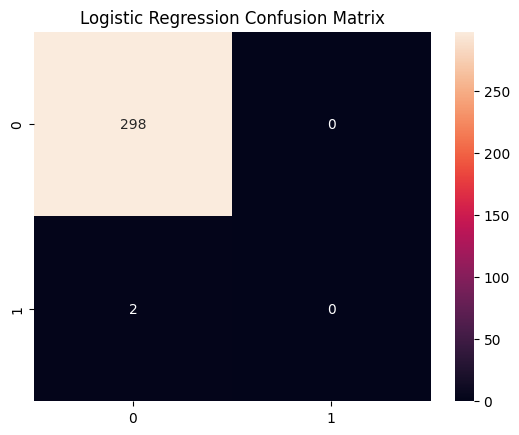

In [6]:
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)


print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Random forest classifier

===== Random Forest Classifier =====
Accuracy: 0.9933333333333333
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       298
           1       0.00      0.00      0.00         2

    accuracy                           0.99       300
   macro avg       0.50      0.50      0.50       300
weighted avg       0.99      0.99      0.99       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


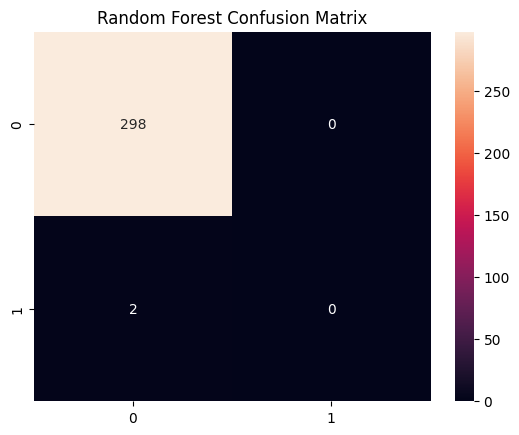

In [7]:
rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


print("===== Random Forest Classifier =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

Feature importance

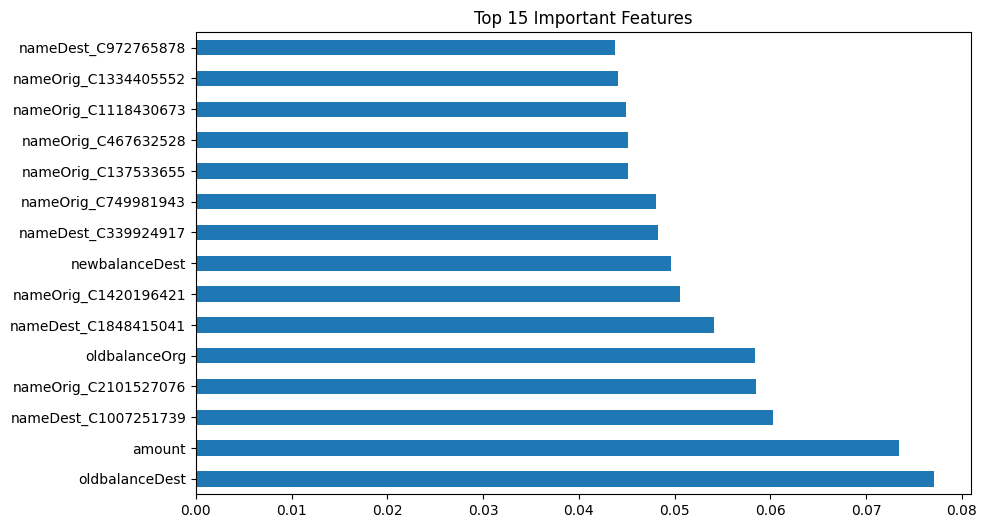

In [8]:
plt.figure(figsize=(10,6))
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()